# 02 - The RL core: cold-start SFT, then GRPO

This is the heart of the DeepSeek-R1 recipe, built from scratch on the same
toy task as notebook 01: **1-digit addition with a think-then-answer
scratchpad**. The single metric we track is **pass-rate** — the fraction of
random additions the model gets right.

Two stages:

- **Stage A - Cold-start SFT.** Teach the model the *format* from ~20 examples.
  This locks in the shape (`think ... answer ...`) but the answers are mostly
  wrong. Expect a low pass-rate.
- **Stage B - GRPO (RL from scratch).** Improve the *skill* with reinforcement
  learning from a rule-based reward. No critic, no value network, no human
  labels. Watch the pass-rate climb.

All the reusable pieces (model, tokenizer, reward, sampling, `pass_rate`) live
in `r1_toy.py` so this notebook stays short and consistent with notebook 03.

> **Marker note.** Here we use compact one-character markers: `T` stands in for
> `<think>` and `A` for `<answer>`, so a format string looks like
> `3+4=T3+4 A7.`. We use the short markers (instead of the readable
> `<think>`/`<answer>` tags from notebook 01) because GRPO needs variety *within
> a group of sampled completions* to get a learning signal; long multi-character
> tags make the model confidently right-or-wrong on a whole prompt, the group's
> rewards become identical, the advantage collapses to zero, and nothing learns.
> The compact answer keeps enough sampling entropy for RL to work. Same idea,
> RL-friendly alphabet.

In [1]:
import torch, torch.nn.functional as F, random
import r1_toy as R   # shared toy machinery (see the file for details)

torch.manual_seed(0); random.seed(0)
print('vocab:', R.VOCAB, '| size:', R.V)
print('example training string:', R.make_example(3, 4))

vocab: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '=', 'T', 'A', ' ', '.'] | size: 16
example training string: 3+4=T3+4 A7.


## Stage A - Cold-start SFT (teach the format)

Supervised fine-tuning on just **20** hand-formatted examples. We are not trying
to make the model good at addition yet — only to make every output *look like*
`... T ... A ... .` so that later the reward function has a format to grade.

In [2]:
# Build a tiny cold-start set: 20 formatted addition examples
examples = R.all_examples()
random.shuffle(examples)
sft_data = examples[:20]
print('cold-start set (20 examples), first 5:')
for ex in sft_data[:5]:
    print('  ', ex)

model = R.TinyLM()
print('-' * 60)
print('params:', round(R.n_params(model), 1), 'K')

cold-start set (20 examples), first 5:
   2+3=T2+3 A5.
   0+8=T0+8 A8.
   1+1=T1+1 A2.
   0+7=T0+7 A7.
   4+8=T4+8 A12.
------------------------------------------------------------
params: 103.6 K


In [3]:
opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
for step in range(400):
    x = R.pad_batch(random.choices(sft_data, k=16))
    logits = model(x[:, :-1])
    loss = F.cross_entropy(logits.reshape(-1, R.V), x[:, 1:].reshape(-1),
                           ignore_index=R.PAD)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 80 == 0:
        print(f'step {step:3d}  loss {loss.item():.3f}')

step   0  loss 2.860


step  80  loss 0.183


step 160  loss 0.104


step 240  loss 0.149


step 320  loss 0.103


In [4]:
# Measure pass-rate after cold-start, and save the checkpoint for stage B / NB3
pr_coldstart = R.pass_rate(model)
torch.save(model.state_dict(), 'nb2_cold_start.pt')

print('-' * 60)
print('sample:', R.generate(model, '3+4='))
print('sample:', R.generate(model, '7+8='))
print('-' * 60)
print(f'PASS-RATE after cold-start SFT: {pr_coldstart:.0%}')
print('saved nb2_cold_start.pt')

------------------------------------------------------------
sample: 3+4=T9+43A9.
sample: 7+8=T7+81A15.
------------------------------------------------------------
PASS-RATE after cold-start SFT: 6%
saved nb2_cold_start.pt


**What to notice:** the outputs now have the right *shape* — `T ... A ... .` —
but the answers are usually wrong. Twenty examples bought us the **format**, not
the **skill**. The pass-rate is low. RL fixes that next.

## Stage B - GRPO from scratch (improve the skill)

**Group Relative Policy Optimization** in four lines of intuition. For each
prompt:

1. **Sample `G` completions** from the *current* model.
2. **Score each** with a rule-based reward (`r1_toy.reward`): a little credit
   for using the format, a lot for the correct answer.
3. **Group-relative advantage:** turn the `G` rewards into z-scores,
   `adv = (r - mean) / (std + eps)`. Completions that beat the group's average
   get positive advantage; below-average ones get negative.
4. **REINFORCE update:** `loss = -(logprob * advantage).mean()` — push the
   policy *toward* better-than-average completions and *away* from worse ones.

There is **no critic, no value network, no human labels**. The other samples in
the group *are* the baseline — "the group is the baseline." The only external
signal is a Python function that can check the answer. This is exactly the R1
idea: **RL from verifiable rewards.**

In [5]:
def grpo_step(prompt_str, G=4):
    # one GRPO update for a single prompt; returns (loss, mean_reward, completions)
    prompt_ids = torch.tensor([R.encode(prompt_str)])
    completions, logps, rewards = [], [], []
    for _ in range(G):
        full, lp = R.sample_completion(model, prompt_ids)   # sample + log-probs
        comp = R.decode(full[0, len(prompt_ids[0]):].tolist())
        completions.append(comp)
        logps.append(lp)
        rewards.append(R.reward(prompt_str, comp))          # rule-based score
    r = torch.tensor(rewards)
    adv = (r - r.mean()) / (r.std() + 1e-6)                  # group-relative advantage
    loss = -(torch.cat(logps) * adv).mean()                 # REINFORCE with advantage
    return loss, r.mean().item(), completions

print('grpo_step defined (G completions -> z-score advantage -> REINFORCE)')

grpo_step defined (G completions -> z-score advantage -> REINFORCE)


In [6]:
opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
mean_reward_hist = []
passrate_hist = []

for step in range(300):
    prompt, a, b = R.random_prompt()
    loss, mean_r, comps = grpo_step(prompt, G=4)
    opt.zero_grad(); loss.backward(); opt.step()
    mean_reward_hist.append(mean_r)
    if step % 30 == 0:
        pr = R.pass_rate(model, n=80)
        passrate_hist.append((step, pr))
        print(f'step {step:3d}  mean_r {mean_r:.2f}  pass-rate~{pr:.0%}   e.g. {prompt}{comps[0]}')

step   0  mean_r 0.08  pass-rate~9%   e.g. 8+4=T8+46+4.


step  30  mean_r 0.33  pass-rate~19%   e.g. 0+9=T0+44A13.


step  60  mean_r 0.03  pass-rate~12%   e.g. 1+7=T1+70A2.


step  90  mean_r 0.08  pass-rate~15%   e.g. 3+5=T9+47A12.


step 120  mean_r 0.83  pass-rate~19%   e.g. 6+6=T6+66A12.


step 150  mean_r 0.10  pass-rate~16%   e.g. 7+2=T7+27A5.


step 180  mean_r 0.10  pass-rate~18%   e.g. 3+5=T4+23A7.


step 210  mean_r 0.10  pass-rate~25%   e.g. 5+9=T5+44A9.


step 240  mean_r 0.08  pass-rate~28%   e.g. 5+5=T4+44A9.


step 270  mean_r 0.10  pass-rate~14%   e.g. 6+1=T9+10A10.


In [7]:
pr_grpo = R.pass_rate(model)
torch.save(model.state_dict(), 'nb2_after_grpo.pt')
print('-' * 60)
print(f'PASS-RATE after cold-start SFT : {pr_coldstart:.0%}')
print(f'PASS-RATE after GRPO          : {pr_grpo:.0%}')
print('-' * 60)
print('saved nb2_after_grpo.pt  (notebook 03 picks up from here)')

------------------------------------------------------------
PASS-RATE after cold-start SFT : 6%
PASS-RATE after GRPO          : 22%
------------------------------------------------------------
saved nb2_after_grpo.pt  (notebook 03 picks up from here)


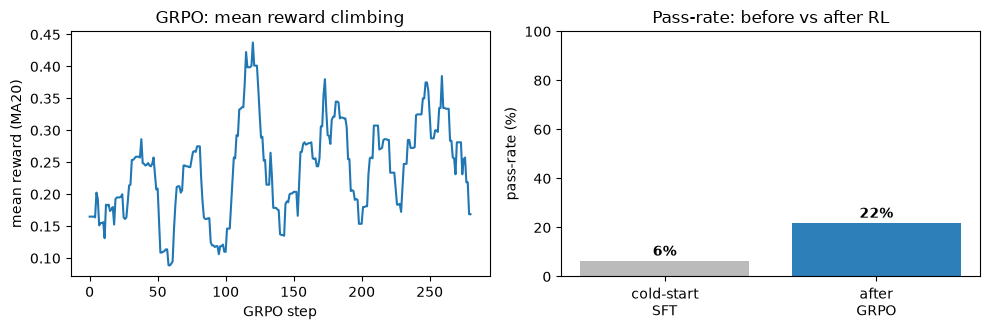

In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

# left: mean reward over training (smoothed)
h = np.array(mean_reward_hist)
if len(h) >= 20:
    ma = np.convolve(h, np.ones(20) / 20, mode='valid')
    ax1.plot(ma)
ax1.set_xlabel('GRPO step'); ax1.set_ylabel('mean reward (MA20)')
ax1.set_title('GRPO: mean reward climbing')

# right: pass-rate before vs after
bars = ax2.bar(['cold-start\nSFT', 'after\nGRPO'],
               [pr_coldstart * 100, pr_grpo * 100],
               color=['#bbbbbb', '#2c7fb8'])
ax2.set_ylabel('pass-rate (%)'); ax2.set_ylim(0, 100)
ax2.set_title('Pass-rate: before vs after RL')
for b in bars:
    ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 2,
             f'{b.get_height():.0f}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## Takeaway

We just ran **reinforcement learning with no critic, no value network, and no
human labels** — only a Python `reward()` function that can check an answer. The
model has the *same architecture and the same parameter count* as after
cold-start; GRPO simply nudged it toward completions that score above their
group's average, and the pass-rate climbed.

**What to notice about RL from verifiable rewards:** whenever you can *check* an
answer with code (math, unit tests, a parser, a game score), you can turn that
checker into a reward and improve a model from its own samples. That is the core
move behind R1-style reasoning training.

Next, in **notebook 03**, we *amplify* this model with rejection sampling and
then *compress* it with distillation.